# Phase 2: how much is 0.917 worth?

The checkpoint reports macro-AUC 0.917 on the 58 radiologist-labelled studies, and Phase 0 showed that
number reproduces. This notebook asks two further questions:

1. **Sampling:** how much would the score move with a different 58 studies of the same kind?
2. **Selection:** how much is it flattered because those same 58 studies were used to pick the checkpoint?

Everything runs from the Phase 0 Kaggle outputs. The backbone features for every window are saved, so only
the small attention head is recomputed here and no GPU is needed.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import evaluation as ev
import plot_style as ps
import raptor_core as rc

ps.apply()
RUN = ROOT / "outputs/kaggle/gold_run"
FIG = ROOT / "outputs/figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)

gold = pd.read_csv(RUN / "gold_labels.csv")
Y = gold[rc.LAB].values.astype(int)
masks = np.load(RUN / "gold_masks_A.npy")
stored = json.load(open(RUN / "summary.json"))["checkpoint"]

## The candidates

The same weights can be scored in several ways: two slice spans (A = 2-98%, the checkpoint's own; B = 6-94%)
times seven window counts, 14 candidates in all. Window subsets come straight from the saved features: every
study has its first and last slice filled, so the centres for any window count are a subset of the 62 used on
Kaggle.

**A24** reproduces the stored AUCs, so it is the reference throughout.

In [2]:
model, _ = rc.load_checkpoint(str(ROOT / "models/raptor_ft_coatnet_v10_full.pt"), "cpu")
ALL_CENTRES = list(range(1, 63))
assert all(rc.eval_centers(m, 62) == ALL_CENTRES for m in masks)

KS = [16, 24, 32, 42, 48, 56, 62]
preds = {}
for span, run in [("A", "A_imagenet"), ("B", "B_imagenet")]:
    feats = torch.from_numpy(np.load(RUN / f"feats_{run}.npy").astype(np.float32))
    for k in KS:
        idx = [ALL_CENTRES.index(c) for c in rc.eval_centers(masks[0], k)]
        with torch.no_grad():
            preds[f"{span}{k}"] = torch.sigmoid(model.head(feats[:, idx])).numpy()

names = list(preds)
macro_orig = np.array([rc.macro_auc(Y, preds[n])[0] for n in names])
pd.DataFrame({"candidate": names, "macro_auc": macro_orig}).set_index("candidate").T

candidate,A16,A24,A32,A42,A48,A56,A62,B16,B24,B32,B42,B48,B56,B62
macro_auc,0.911,0.918,0.913,0.916,0.915,0.917,0.917,0.912,0.923,0.916,0.92,0.92,0.921,0.922


## 1. One number, 58 studies: bootstrap and DeLong intervals

Two ways to put an interval around an AUC.

**Bootstrap.** Treat the 58 studies as the population: draw 58 with replacement, recompute, repeat 10,000
times, and read the spread. Resample *studies*, not windows or findings. The study is what was sampled, and
its twelve labels are correlated (a torn ACL comes with effusion and contusion).

**DeLong.** AUC is the probability that a random positive study outranks a random negative one. Give each
positive its *placement* (the fraction of negatives it beats) and each negative the fraction of positives that
beat it. The AUC is the mean of either set, and its variance follows from the variance of the placements.
There is no resampling, and the same algebra gives the covariance between two models scored on the same studies.

In [3]:
B = 10_000
W = ev.bootstrap_weights(len(Y), B, seed=2646)
boot = {n: ev.bootstrap_aucs(Y, preds[n], W) for n in names}          # each [B, 12]
macro_boot = np.stack([np.nanmean(boot[n], axis=1) for n in names], axis=1)   # [B, V]

REF = "A24"
P_ref = preds[REF]
lo, hi = ev.percentile_ci(boot[REF])
rows = []
for j, f in enumerate(rc.LAB):
    a, se, dlo, dhi = ev.delong_ci(Y[:, j], P_ref[:, j])
    npos = int(Y[:, j].sum())
    rows.append({"finding": f, "positives": npos, "negatives": len(Y) - npos, "auc": a,
                 "boot_lo": lo[j], "boot_hi": hi[j], "delong_lo": dlo, "delong_hi": dhi,
                 "delong_se": se, "boot_sd": np.nanstd(boot[REF][:, j])})
per_finding = pd.DataFrame(rows).set_index("finding")
m_lo, m_hi = ev.percentile_ci(macro_boot[:, names.index(REF)])
print(f"{REF} macro-AUC {macro_orig[names.index(REF)]:.4f}  95% bootstrap CI [{m_lo:.4f}, {m_hi:.4f}]  "
      f"SD {macro_boot[:, names.index(REF)].std():.4f}")
per_finding.sort_values("auc")

A24 macro-AUC 0.9183  95% bootstrap CI [0.8938, 0.9403]  SD 0.0119


,positives,negatives,auc,boot_lo,boot_hi,delong_lo,delong_hi,delong_se,boot_sd
finding,,,,,,,,,
Synovitis,27,31,0.798,0.672,0.908,0.679,0.918,0.061,0.061
PF OA,21,37,0.838,0.707,0.946,0.717,0.959,0.062,0.061
Lateral Meniscus,23,35,0.847,0.738,0.936,0.748,0.946,0.050,0.051
Lateral OA,11,47,0.892,0.783,0.975,0.797,0.987,0.049,0.049
Fracture,18,40,0.912,0.824,0.978,0.836,0.989,0.039,0.040
Contusion,19,39,0.931,0.852,0.988,0.863,0.999,0.035,0.035
Medial Meniscus,26,32,0.945,0.878,0.990,0.889,1.000,0.029,0.029
MCL,9,49,0.959,0.879,1.000,0.894,1.000,0.033,0.034
Medial OA,15,43,0.964,0.912,0.998,0.922,1.000,0.022,0.023


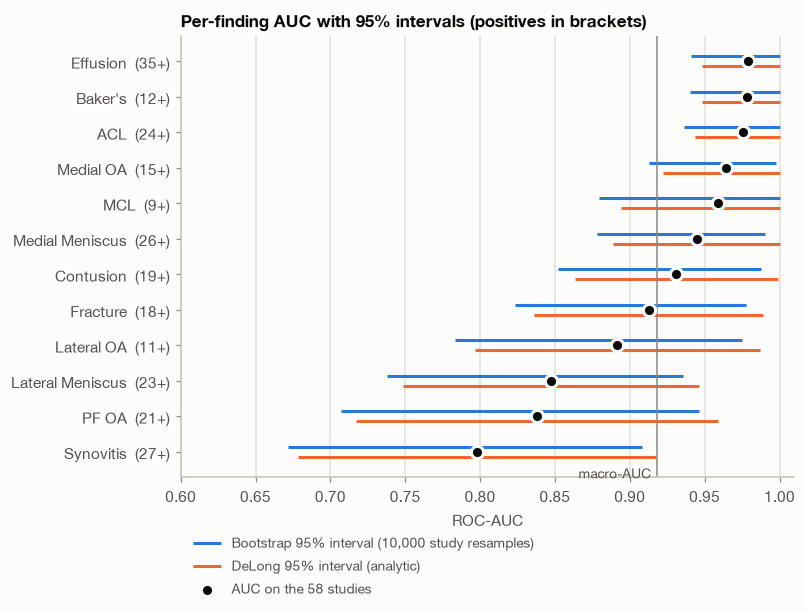

In [4]:
order = per_finding.sort_values("auc").index
yy = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.hlines(yy + 0.14, per_finding.loc[order, "boot_lo"], per_finding.loc[order, "boot_hi"],
          color=ps.BLUE, lw=2, label="Bootstrap 95% interval (10,000 study resamples)")
ax.hlines(yy - 0.14, per_finding.loc[order, "delong_lo"], per_finding.loc[order, "delong_hi"],
          color=ps.ORANGE, lw=2, label="DeLong 95% interval (analytic)")
ax.scatter(per_finding.loc[order, "auc"], yy, s=64, color=ps.INK, zorder=3,
           edgecolor=ps.SURFACE, linewidth=2, label="AUC on the 58 studies")
ax.axvline(macro_orig[names.index(REF)], color=ps.MUTED, lw=1)
ax.text(macro_orig[names.index(REF)] - 0.004, -0.75, "macro-AUC", color=ps.INK_2, fontsize=9, ha="right")
ax.set_yticks(yy, [f"{f}  ({per_finding.loc[f, 'positives']}+)" for f in order])
ax.set_xlim(0.6, 1.01)
ax.set_xlabel("ROC-AUC")
ax.grid(axis="y", visible=False)
ax.set_title("Per-finding AUC with 95% intervals (positives in brackets)")
ax.legend(loc="lower left", bbox_to_anchor=(0, -0.30), ncol=1, fontsize=9)
fig.savefig(FIG / "phase2_forest.png")
plt.show()

**Reading the intervals**

- **Macro-AUC 0.918, 95% interval [0.894, 0.940]**, roughly ±0.023. Reporting it to four decimals means
  three of them are noise.
- **Per finding the intervals are up to 5 times wider** (Effusion 1.3 times, Synovitis 5). Synovitis could plausibly be anywhere from 0.67 to 0.91,
  PF OA from 0.71 to 0.95. The macro average is tighter because errors on twelve findings partly cancel.
- **The rarer class sets the width, not the number of studies.** MCL has 9 positives and an interval as wide
  as Medial Meniscus with 26, despite scoring higher. Intervals also narrow near 1.0, where there is less room
  to be wrong.
- **DeLong and the bootstrap agree on the size** of the uncertainty: standard errors within 0.001 on every
  finding. They differ in *shape*. DeLong's interval is symmetric and runs into the 1.0 ceiling, where it is
  clipped. The bootstrap interval bends away from the ceiling, which is the more honest picture for AUCs above 0.95.

## 2. Is the 6-94% span really better? Paired comparisons

Phase 0 found the older 6-94% span scoring 0.922 against 0.917 for the checkpoint's own span. Separate
intervals cannot settle that: each is about ±0.023 wide, and they overlap almost entirely.

Both spans are scored on the *same* 58 studies, though, so most of their luck is shared: a study that is hard
under span A is hard under span B. A **paired** comparison scores both on the same resample and looks only at
the difference, and the shared luck cancels.

In [5]:
def paired(a, b):
    ia, ib = names.index(a), names.index(b)
    d = macro_boot[:, ib] - macro_boot[:, ia]
    dlo, dhi = ev.percentile_ci(d)
    ua_lo, ua_hi = ev.percentile_ci(macro_boot[:, ia])
    ub_lo, ub_hi = ev.percentile_ci(macro_boot[:, ib])
    return {"comparison": f"{b} - {a}", "observed_diff": macro_orig[ib] - macro_orig[ia],
            "paired_ci_lo": dlo, "paired_ci_hi": dhi, "sd_diff": d.std(), "p_b_better": (d > 0).mean(),
            f"corr": np.corrcoef(macro_boot[:, ia], macro_boot[:, ib])[0, 1],
            "unpaired_overlap": min(ua_hi, ub_hi) - max(ua_lo, ub_lo)}

comparisons = pd.DataFrame([paired("A62", "B62"), paired("A24", "B24"), paired("A24", "A62")]).set_index("comparison")
comparisons

,observed_diff,paired_ci_lo,paired_ci_hi,sd_diff,p_b_better,corr,unpaired_overlap
comparison,,,,,,,
B62 - A62,0.005,-9.403e-04,0.011,0.003,0.947,0.969,0.043
B24 - A24,0.005,-3.568e-03,0.014,0.005,0.874,0.928,0.042
A62 - A24,-0.001,-9.579e-03,0.007,0.004,0.383,0.940,0.046


In [6]:
# The same question finding by finding, with DeLong's paired test.
rows = []
for j, f in enumerate(rc.LAB):
    d, se, p = ev.delong_paired(Y[:, j], preds["A62"][:, j], preds["B62"][:, j])
    rows.append({"finding": f, "B62 - A62": d, "se": se, "p": p})
pd.DataFrame(rows).set_index("finding")

,B62 - A62,se,p
finding,,,
ACL,0.000,0.002,1.000
MCL,0.007,0.011,0.531
Medial Meniscus,0.006,0.009,0.488
Lateral Meniscus,0.014,0.015,0.350
Medial OA,0.002,0.004,0.685
Lateral OA,0.008,0.012,0.520
PF OA,0.003,0.008,0.756
Effusion,0.000,0.004,1.000
Synovitis,0.016,0.012,0.188


findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for Arial, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


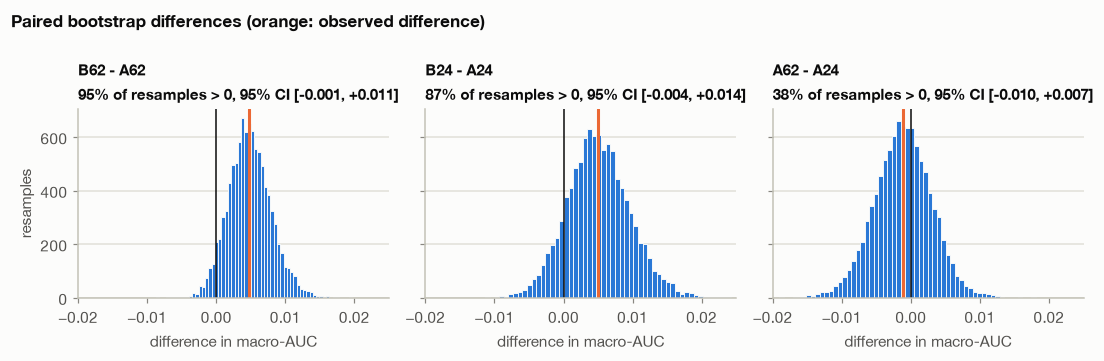

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), sharex=True, sharey=True)
for ax, (label, row) in zip(axes, comparisons.iterrows()):
    b_name, a_name = [s.strip() for s in label.split("-")]
    d = macro_boot[:, names.index(b_name)] - macro_boot[:, names.index(a_name)]
    ax.hist(d, bins=60, color=ps.BLUE, edgecolor=ps.SURFACE, linewidth=0.6)
    ax.axvline(0, color=ps.INK, lw=1)
    ax.axvline(row.observed_diff, color=ps.ORANGE, lw=2)
    ax.set_title(f"{label}\n{row.p_b_better:.0%} of resamples > 0, 95% CI [{row.paired_ci_lo:+.3f}, {row.paired_ci_hi:+.3f}]",
                 fontsize=9.5, linespacing=1.5)
    ax.set_xlabel("difference in macro-AUC")
    ax.set_xlim(-0.02, 0.025)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("resamples")
fig.suptitle("Paired bootstrap differences (orange: observed difference)", x=0.01, ha="left",
             fontsize=11, fontweight="semibold")
fig.tight_layout()
fig.savefig(FIG / "phase2_paired.png")
plt.show()

**Reading the paired results**

- **Pairing cuts the uncertainty by 3-4 times.** Across resamples the macro-AUCs of A62 and B62 correlate
  at 0.97, so their difference has SD 0.003, against 0.012 for either score alone.
- **B62 beats A62 in 95% of resamples**, with a 95% interval of [-0.001, +0.011]. That is suggestive, not
  conclusive. No single finding differs significantly (smallest DeLong p = 0.19, Synovitis), and at 24
  windows the case is weaker (87%).
- **62 windows versus 24 makes no measurable difference** (-0.001, better in only 38% of resamples).
- The interesting part is not that B might be better. The checkpoint was trained on span A and *loses
  nothing* on a slice set it never saw, so the outermost 2-6% of each series carries no signal it depends on.

How small a difference could these 58 studies detect at all? For a paired test with 80% power at
α = 0.05, roughly (1.96 + 0.84) times the SD of the difference:

In [8]:
from scipy.stats import norm

typical_sd_diff = comparisons["sd_diff"].median()
mdd = (norm.ppf(0.975) + norm.ppf(0.80)) * typical_sd_diff
print(f"typical SD of a paired macro-AUC difference: {typical_sd_diff:.4f}")
print(f"smallest true difference detected 80% of the time at alpha 0.05: {mdd:.4f}")

typical SD of a paired macro-AUC difference: 0.0042
smallest true difference detected 80% of the time at alpha 0.05: 0.0117


## 3. Selection optimism

### 3a. Choosing among the 14 candidates on the same 58 studies

Every choice made by looking at the gold score (which epoch, which span, how many windows) biases the
winner upward. Among near-equal candidates, the one that wins is partly the one that got lucky on these
particular 58 studies.

For an explicit set of candidates the bootstrap can measure this (Efron-Tibshirani optimism, popularised by
Harrell). In each resample, pick the candidate that looks best *on the resample*, then score that same
candidate on the original 58. The resample plays "the set you selected on" and the original plays "new data".
The average gap is the optimism of the selection procedure.

apparent winner on the 58 studies: B24 at 0.9233
estimated optimism of picking the best of 14: +0.0035
optimism-corrected score of the selection procedure: 0.9198


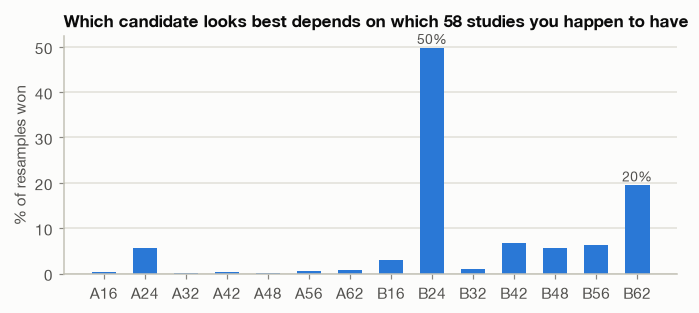

In [9]:
best_orig = names[int(np.argmax(macro_orig))]
opt_mean, opt_b, wins = ev.selection_optimism_bootstrap(macro_orig, macro_boot)
print(f"apparent winner on the 58 studies: {best_orig} at {macro_orig.max():.4f}")
print(f"estimated optimism of picking the best of {len(names)}: {opt_mean:+.4f}")
print(f"optimism-corrected score of the selection procedure: {macro_orig.max() - opt_mean:.4f}")

fig, ax = plt.subplots(figsize=(7.2, 2.8))
x = np.arange(len(names))
ax.bar(x, wins * 100, width=0.6, color=ps.BLUE)
ax.set_xticks(x, names)
ax.set_ylabel("% of resamples won")
ax.grid(axis="x", visible=False)
ax.set_title("Which candidate looks best depends on which 58 studies you happen to have")
for i in np.argsort(wins)[-2:]:
    ax.text(i, wins[i] * 100 + 0.8, f"{wins[i]:.0%}", ha="center", fontsize=9, color=ps.INK_2)
fig.savefig(FIG / "phase2_winners.png")
plt.show()

**Reading it.** On the real 58 studies B24 looks best (0.923), but it wins only half the resamples. B62 takes
a fifth, and the rest is spread thin. Picking the best of these 14 carries an estimated optimism of +0.0035,
so "choose the best configuration on this set" is worth about 0.920 on new studies. That is still above A24,
but by less than the smallest difference this set can detect.

### 3b. Choosing the best training epoch

The checkpoint is the best epoch of its training run (epoch 12), chosen by gold macro-AUC. Its sibling epochs
were never published, so their optimism cannot be bootstrapped. A noise model gives a range instead.

Split each epoch's gold score into three parts: its true score, luck shared by every epoch (these 58 studies
are easy or hard for all of them), and luck specific to that epoch. Only the epoch-specific part can make one
epoch *look* better than another. If n epochs are truly equal, the winner's expected inflation is

$$\text{optimism} \approx \frac{\text{SD of the score difference between two epochs}}{\sqrt{2}} \times \mathbb{E}[\max \text{ of } n \text{ standard normals}]$$

The expected maximum is 1.03 for 3 epochs and 1.77 for 16. The one unknown is how much two epochs' scores
differ. We measured that for models sharing identical weights (0.003-0.004). Late epochs of a real run differ
more than that, so twice the larger anchor is included as a plausible upper case.

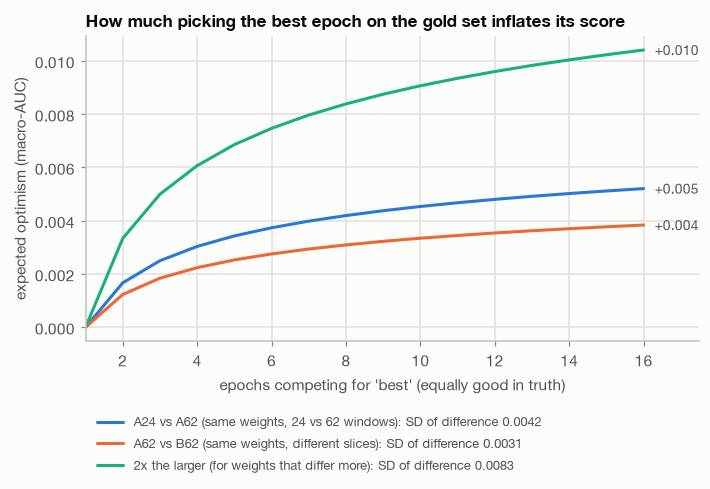

,"A24 vs A62 (same weights, 24 vs 62 windows)","A62 vs B62 (same weights, different slices)",2x the larger (for weights that differ more)
best of 3,0.002,0.002,0.005
best of 6,0.004,0.003,0.007
best of 16,0.005,0.004,0.010


In [10]:
anchors = {
    "A24 vs A62 (same weights, 24 vs 62 windows)": comparisons.loc["A62 - A24", "sd_diff"],
    "A62 vs B62 (same weights, different slices)": comparisons.loc["B62 - A62", "sd_diff"],
}
anchors["2x the larger (for weights that differ more)"] = 2 * max(anchors.values())
ns = np.arange(1, 17)
emax = np.array([ev.expected_max_std_normal(int(n)) for n in ns])

fig, ax = plt.subplots(figsize=(7.2, 3.6))
for (label, sd), colour in zip(anchors.items(), [ps.BLUE, ps.ORANGE, ps.AQUA]):
    curve = sd / np.sqrt(2) * emax
    ax.plot(ns, curve, color=colour, label=f"{label}: SD of difference {sd:.4f}")
    ax.text(ns[-1] + 0.3, curve[-1], f"{curve[-1]:+.3f}", va="center", fontsize=9, color=ps.INK_2)
ax.set_xlim(1, 17.5)
ax.set_xlabel("epochs competing for 'best' (equally good in truth)")
ax.set_ylabel("expected optimism (macro-AUC)")
ax.set_title("How much picking the best epoch on the gold set inflates its score")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), fontsize=8.5)
fig.savefig(FIG / "phase2_epoch_optimism.png")
plt.show()

table = pd.DataFrame({label: [ev.epoch_selection_optimism(sd, n) for n in (3, 6, 16)] for label, sd in anchors.items()},
                     index=["best of 3", "best of 6", "best of 16"])
table

## 4. What to believe

| | macro-AUC |
|---|---|
| Stored in the checkpoint | 0.917 |
| Reproduced (A24) | 0.918 |
| 95% interval from sampling 58 studies | 0.894 to 0.940 |
| Epoch-selection optimism (best of 3 to 16 epochs) | -0.002 to -0.010 |
| **Plausible score on fresh studies like these** | **about 0.91, ± 0.02** |

Three lessons that carry beyond this model:

1. **On 58 studies, macro-AUC is uncertain to about ±0.02 and a single finding to ±0.05-0.12.** Even with the
   best paired test, differences below about 0.012 cannot be reliably detected. The author's development notes
   report a +0.013 gain as "better in 92.7% of 2000 bootstraps", which sits right at that limit.
2. **Compare models paired on the same studies.** Separate intervals throw away most of the signal.
3. **One selection step costs little; many add up.** Near-identical candidates share most of their luck, so
   picking among them inflates the score by only a few thousandths. This checkpoint's lineage, though, made
   many choices on the same labelled studies: the epoch, the slice geometry (several variants published as
   separate datasets), and an architecture panel selected "by greedy forward selection and exhaustive subset
   search" on an earlier 45-study version of the set. None of that can be bootstrapped from here. That is why an
   independent test set, for this competition the hidden leaderboard, is the only real check.